In [11]:
!pip install fastapi uvicorn pandas sqlalchemy pyngrok nest_asyncio

In [12]:
import os

os.makedirs("/content/backend", exist_ok=True)

In [14]:
from sqlalchemy import create_engine

# SQLite replaces SQL Server
engine = create_engine("sqlite:///workflow.db")

def get_connection():
    return engine.connect()

In [15]:
import pandas as pd

def load_public_dataset():
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)

    df = df[['PassengerId', 'Name', 'Pclass', 'Age', 'Sex', 'Survived']]
    df.columns = ['customer_id', 'name', 'priority', 'age', 'gender', 'completed']

    df['age'] = df['age'].fillna(df['age'].mean())
    return df


def generate_workflow_tasks(df):
    tasks = []

    for _, row in df.iterrows():
        tasks.append({
            "customer_id": int(row["customer_id"]),
            "task": "Verify Documents" if row["priority"] == 1 else "Standard Onboarding",
            "status": "Pending" if row["completed"] == 0 else "Completed",
            "exception_flag": bool(row["age"] > 60)
        })

    return tasks

In [16]:
from fastapi import FastAPI

app = FastAPI(title="Workflow Automation Platform")

DATA = load_public_dataset()
TASKS = generate_workflow_tasks(DATA)


@app.get("/")
def home():
    return {"message": "Workflow Automation Platform Running Successfully"}


@app.get("/customers")
def get_customers():
    return DATA.head(10).to_dict(orient="records")


@app.get("/tasks")
def get_tasks():
    return TASKS[:20]


@app.post("/generate-workflow")
def regenerate_workflow():
    global TASKS
    TASKS = generate_workflow_tasks(DATA)
    return {"status": "Workflow regenerated", "total_tasks": len(TASKS)}

In [17]:
import nest_asyncio
nest_asyncio.apply()

In [20]:
from pyngrok import ngrok

ngrok.set_auth_token("3G2mxGntJZwecFdDd2KMrWFDRMm_3BjLKUpJ8cpMCgMA5fjdi")

In [34]:
!pip install fastapi uvicorn pyngrok nest_asyncio

In [52]:
from pyngrok import ngrok

ngrok.kill()
print("All ngrok tunnels closed")

All ngrok tunnels closed


In [54]:
import subprocess
import time
from pyngrok import ngrok

ngrok.kill()

# start server
process = subprocess.Popen([
    "uvicorn",
    "app:app",
    "--host", "0.0.0.0",
    "--port", "8000"
])

time.sleep(5)

# new tunnel
public_url = ngrok.connect(8000)

print("NEW PUBLIC URL:", public_url.public_url)

NEW PUBLIC URL: https://retorted-overview-camisole.ngrok-free.dev


In [55]:
from pyngrok import ngrok

ngrok.set_auth_token("3G2mxGntJZwecFdDd2KMrWFDRMm_3BjLKUpJ8cpMCgMA5fjdi")

public_url = ngrok.connect(8000)

print("PUBLIC URL:", public_url.public_url)

PUBLIC URL: https://retorted-overview-camisole.ngrok-free.dev


In [56]:
import requests

url = public_url.public_url

res = requests.get(url + "/")

print(res.status_code)
print(res.json())

200
{'status': 'WORKING'}


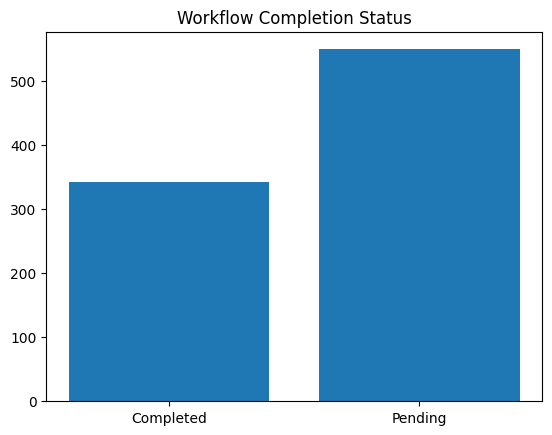

In [57]:
import matplotlib.pyplot as plt

completed = sum(task["status"] == "Completed" for task in TASKS)
pending = sum(task["status"] == "Pending" for task in TASKS)

labels = ["Completed", "Pending"]
values = [completed, pending]

plt.figure()
plt.bar(labels, values)
plt.title("Workflow Completion Status")
plt.show()

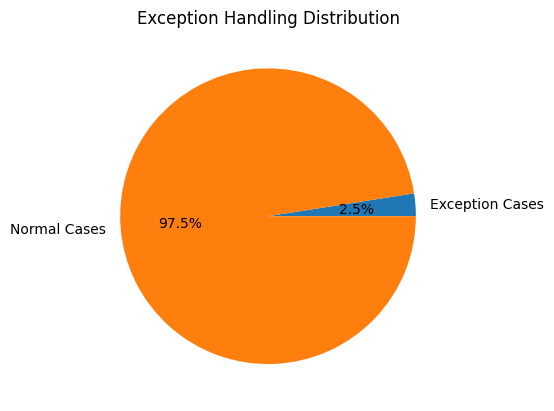

In [58]:
exceptions = sum(task["exception_flag"] for task in TASKS)
normal = len(TASKS) - exceptions

labels = ["Exception Cases", "Normal Cases"]
values = [exceptions, normal]

plt.figure()
plt.pie(values, labels=labels, autopct="%1.1f%%")
plt.title("Exception Handling Distribution")
plt.show()

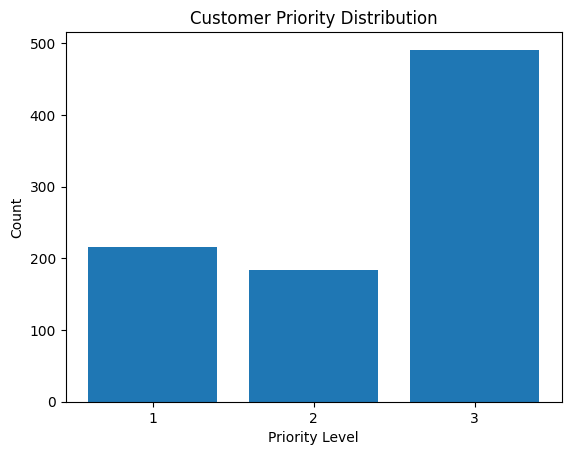

In [59]:
import pandas as pd

df = DATA.copy()

priority_counts = df["priority"].value_counts().sort_index()

plt.figure()
plt.bar(priority_counts.index.astype(str), priority_counts.values)
plt.title("Customer Priority Distribution")
plt.xlabel("Priority Level")
plt.ylabel("Count")
plt.show()